In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('Student_Performance.csv')
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [5]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
school_type,0
parent_education,0
study_hours,0
attendance_percentage,0
internet_access,0
travel_time,0
extra_activities,0


In [6]:
df = df.drop_duplicates()

In [7]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [8]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [9]:
df.describe()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,16.476400,1.00420,0.494200,2.483933,4.25936,74.991760,0.850267,1.483800,0.499600,2.519867,63.774553,63.751227,63.709227,64.015500,2.855600
std,4330.271354,1.704475,0.81737,0.499983,1.717733,2.17244,14.401139,0.356822,1.120277,0.500017,1.700686,20.919958,21.027675,20.860201,18.977811,1.341368
min,1.000000,14.000000,0.00000,0.000000,0.000000,0.50000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.500000,0.000000
25%,3750.750000,15.000000,0.00000,0.000000,1.000000,2.40000,62.600000,1.000000,0.000000,0.000000,1.000000,48.200000,48.100000,48.300000,49.000000,2.000000
50%,7500.500000,16.000000,1.00000,0.000000,2.000000,4.30000,75.000000,1.000000,1.000000,0.000000,3.000000,64.100000,64.000000,64.200000,64.300000,3.000000
75%,11250.250000,18.000000,2.00000,1.000000,4.000000,6.10000,87.400000,1.000000,2.000000,1.000000,4.000000,80.100000,80.100000,80.000000,79.100000,4.000000
max,15000.000000,19.000000,2.00000,1.000000,5.000000,8.00000,100.000000,1.000000,3.000000,1.000000,5.000000,100.000000,100.000000,100.000000,100.000000,5.000000


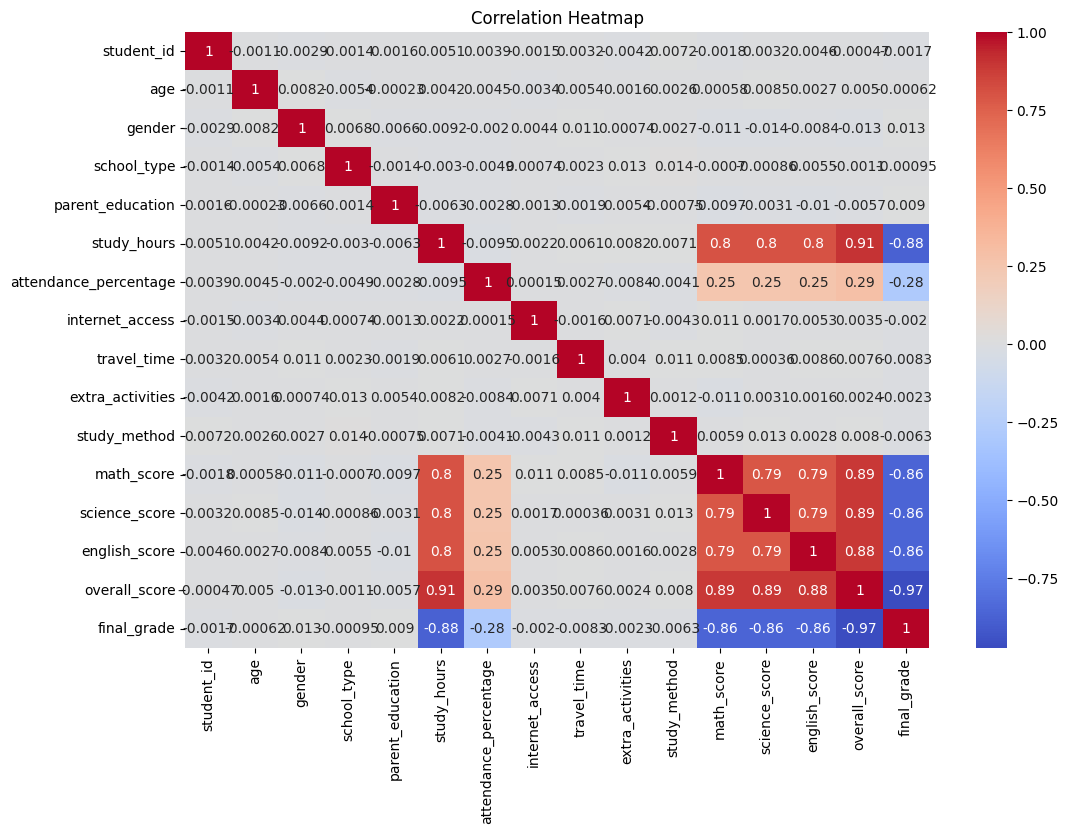

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [19]:
X = df.drop('overall_score', axis=1)
y = df['overall_score']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2.417234333333333
RMSE: 3.0019772284834763
R² Score: 0.975594816966231


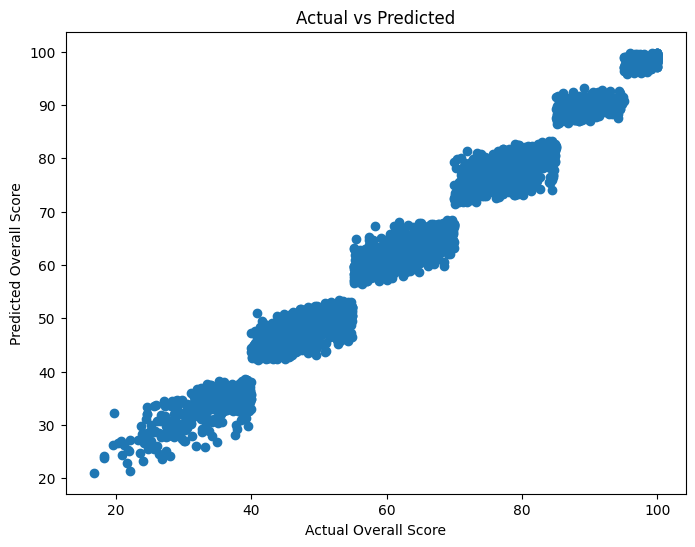

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Overall Score')
plt.ylabel('Predicted Overall Score')
plt.title('Actual vs Predicted')
plt.show()

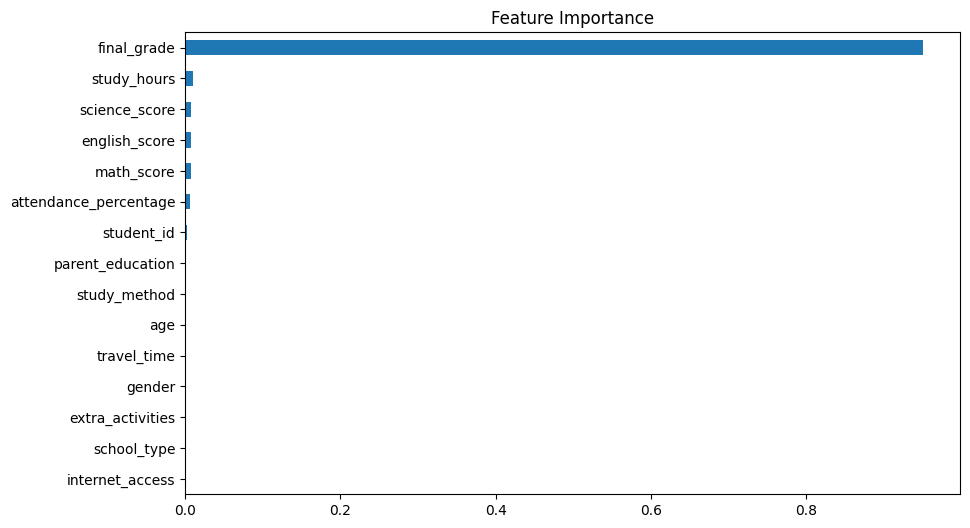

In [25]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Feature Importance')
plt.show()